In [5]:
!pip install git+https://github.com/huggingface/transformers
!pip install matplotlib

In [2]:
from huggingface_hub import notebook_login
notebook_login()


In [3]:
from io import BytesIO
import torch
import httpx
from transformers import AutoModel, AutoProcessor
from PIL import Image

# 1. Load and Quantize for CPU
model = AutoModel.from_pretrained("yonigozlan/sam3-litetext-s0")
model = torch.quantization.quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)
model.eval()

processor = AutoProcessor.from_pretrained("yonigozlan/sam3-litetext-s0")

# 2. Fetch and Downsize Image


Loading weights:   0%|          | 0/1204 [00:00<?, ?it/s]

/tmp/ipykernel_49702/1565179711.py:9: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)


In [6]:
image_url = "http://images.cocodataset.org/val2017/000000077595.jpg"
image = Image.open(BytesIO(httpx.get(image_url).content)).convert("RGB")
image.thumbnail((1024, 1024)) # Prevents post-processing RAM spikes
prompt="laptop"
# 3. Inference with no-grad
with torch.inference_mode():
    inputs = processor(images=image, text=prompt, return_tensors="pt").to('cpu')
    outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.5,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

print(f"Found {len(results['masks'])} objects")

Found 1 objects


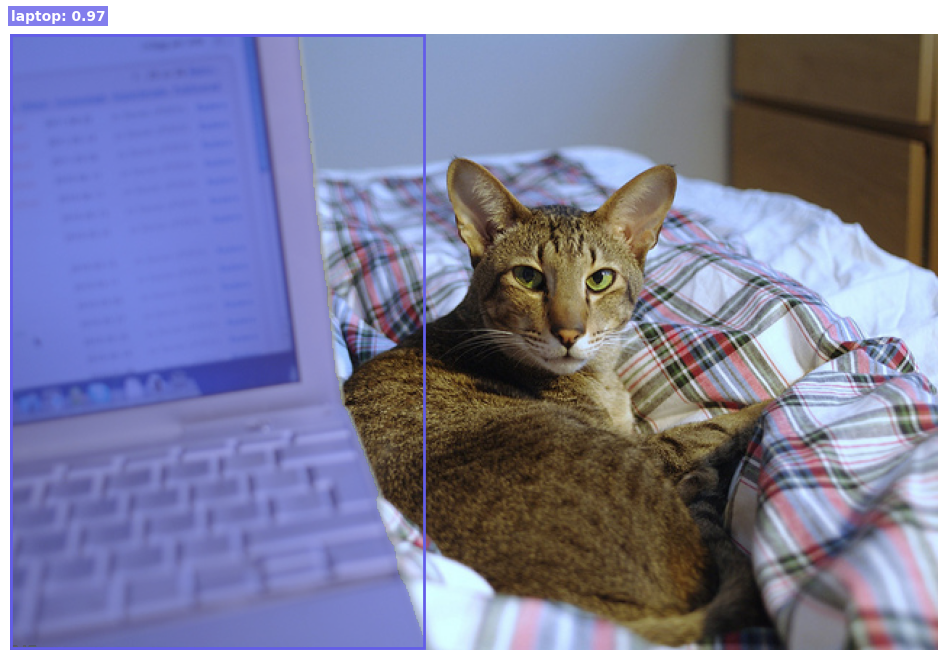

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_results(img, results, label_text):
    masks = results["masks"].cpu().numpy()
    scores = results["scores"].cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)

    for i, (mask, score) in enumerate(zip(masks, scores)):
        # Generate a distinct color for this instance
        color = np.random.rand(3)

        # Draw Mask overlay (40% opacity)
        mask_overlay = np.zeros((*mask.shape, 4))
        mask_overlay[mask > 0] = np.concatenate([color, [0.4]])
        ax.imshow(mask_overlay)

        # Calculate Bounding Box from the mask pixels
        y, x = np.where(mask > 0)
        if len(x) > 0 and len(y) > 0:
            x_min, x_max = x.min(), x.max()
            y_min, y_max = y.min(), y.max()

            # Add Rectangle Patch
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Add Label and Confidence Score
            ax.text(
                x_min, y_min - 10, f"{label_text}: {score:.2f}",
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=2)
            )

    plt.axis('off')
    plt.show()

if len(results['masks']) > 0:
    visualize_results(image, results, prompt)
else:
    print("No objects detected above the threshold.")